# Configuracion de carpeta de datos

La competencia elegida para este EDA se encuentra en el siguiente [Enlace](https://www.kaggle.com/competitions/hull-tactical-market-prediction/**overview**)

## Si se ejecuta desde Google Colab ejecuta la siguiente celda

In [ ]:
# Montar drive para datos persistentes
from google.colab import drive
drive.mount('/content/drive')
content_path = "/content/drive/MyDrive/data/mercado"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Si se ejecuta localmente ejecuta la siguiente celda

In [ ]:
!pip install pandas numpy matplotlib seaborn

content_path = "hull-tactical-market-prediction"

# 1. Importar Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carga de datos

In [ ]:
df = pd.read_csv(f'{content_path}/train.csv')

# 3. Entendiendo las variables


In [ ]:
# Forma del dataset
print(f'-> Forma del dataset \n  Filas: {df.shape[0]:,}, Columnas: {df.shape[1]}')

print(f'\n-> Primeras 5 filas \n\n {df.head(5)}')

print(f'\n-> Información de las columnas \n\n {df.dtypes}')

-> Forma del dataset 
  Filas: 9,021, Columnas: 98

-> Primeras 5 filas 

    date_id  D1  D2  D3  D4  D5  D6  D7  D8  D9  ...  V3  V4  V5  V6  V7  V8  \
0        0   0   0   0   1   1   0   0   0   1  ... NaN NaN NaN NaN NaN NaN   
1        1   0   0   0   1   1   0   0   0   1  ... NaN NaN NaN NaN NaN NaN   
2        2   0   0   0   1   0   0   0   0   1  ... NaN NaN NaN NaN NaN NaN   
3        3   0   0   0   1   0   0   0   0   0  ... NaN NaN NaN NaN NaN NaN   
4        4   0   0   0   1   0   0   0   0   0  ... NaN NaN NaN NaN NaN NaN   

   V9  forward_returns  risk_free_rate  market_forward_excess_returns  
0 NaN        -0.002421        0.000301                      -0.003038  
1 NaN        -0.008495        0.000303                      -0.009114  
2 NaN        -0.009624        0.000301                      -0.010243  
3 NaN         0.004662        0.000299                       0.004046  
4 NaN        -0.011686        0.000299                      -0.012301  

[5 rows x 98 colu

In [ ]:
# Identificación de grupos de características
feature_groups = {
    'Market Dynamics/Technical': [col for col in df.columns if col.startswith('M')],
    'Macro Economic': [col for col in df.columns if col.startswith('E')],
    'Interest Rate': [col for col in df.columns if col.startswith('I')],
    'Price/Valuation': [col for col in df.columns if col.startswith('P')],
    'Volatility': [col for col in df.columns if col.startswith('V')],
    'Sentiment': [col for col in df.columns if col.startswith('S')],
    'Momentum': [col for col in df.columns if col.startswith('MOM')],
    'Dummy/Binary': [col for col in df.columns if col.startswith('D')],
    'Target/Key': ['date_id', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']
}

print(f'\n-> Identificación de grupos de características \n\n')
for group, cols in feature_groups.items():
    print(f"{group}: {len(cols)} características")


-> Identificación de grupos de características 


Market Dynamics/Technical: 18 características
Macro Economic: 20 características
Interest Rate: 9 características
Price/Valuation: 13 características
Volatility: 13 características
Sentiment: 12 características
Momentum: 0 características
Dummy/Binary: 9 características
Target/Key: 4 características


In [ ]:
print(f'\n-> Número de valores únicos por columna \n\n {df.nunique(axis=0).sort_values(ascending=False)}')

print(f'\n-> Estadísticas básicas \n\n {df.describe().T}')




-> Número de valores únicos por columna 

 date_id                          9021
market_forward_excess_returns    9019
forward_returns                  8942
E3                               8015
E19                              8015
                                 ... 
D6                                  2
D5                                  2
D4                                  2
D3                                  2
D2                                  2
Length: 98, dtype: int64

-> Estadísticas básicas 

                                 count         mean          std       min  \
date_id                        9021.0  4510.000000  2604.282723  0.000000   
D1                             9021.0     0.031593     0.174923  0.000000   
D2                             9021.0     0.031593     0.174923  0.000000   
D3                             9021.0     0.047777     0.213307  0.000000   
D4                             9021.0     0.573994     0.494522  0.000000   
...                    

In [ ]:
# Análisis de las variables objetivo
target_cols = ['forward_returns', 'risk_free_rate', 'market_forward_excess_returns']

print(f'\n->Análisis de las variables objetivo')
for col in target_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].describe())


->Análisis de las variables objetivo

forward_returns:
count    9021.000000
mean        0.000471
std         0.010541
min        -0.039754
25%        -0.004319
50%         0.000659
75%         0.005896
max         0.040661
Name: forward_returns, dtype: float64

risk_free_rate:
count    9021.000000
mean        0.000107
std         0.000088
min        -0.000004
25%         0.000008
50%         0.000097
75%         0.000193
max         0.000317
Name: risk_free_rate, dtype: float64

market_forward_excess_returns:
count    9021.000000
mean        0.000053
std         0.010558
min        -0.040582
25%        -0.004747
50%         0.000255
75%         0.005479
max         0.040551
Name: market_forward_excess_returns, dtype: float64


# 4. Limpiando el dataset



In [ ]:
df_cleaned = df.copy()

In [ ]:
# Análisis de valores faltantes
missing_values = df_cleaned.isna().sum()
missing_percent = (missing_values / len(df_cleaned)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percent': missing_percent
}).sort_values('Missing_Percent', ascending=False)

print(missing_df[missing_df['Missing_Percent'] > 0])

     Missing_Count  Missing_Percent
E7            6969        77.253076
V10           6049        67.054650
S3            5733        63.551713
M1            5547        61.489857
M13           5540        61.412260
..             ...              ...
P9            1006        11.151757
P8            1006        11.151757
V8            1006        11.151757
V6            1006        11.151757
V2            1006        11.151757

[85 rows x 2 columns]


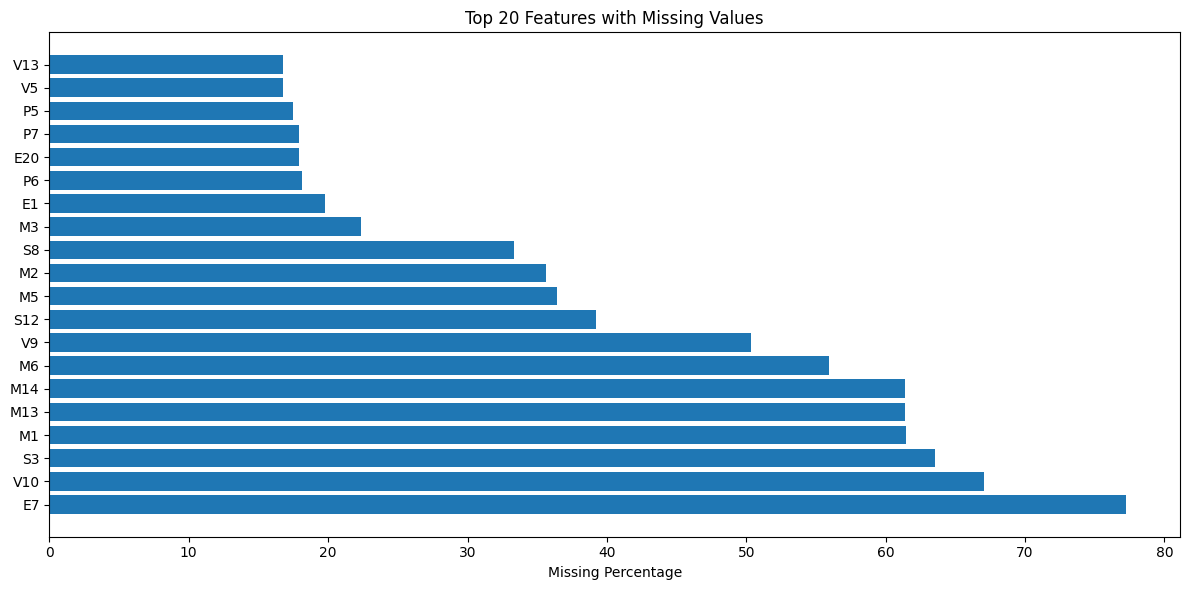

In [ ]:
# Visualización de valores faltantes
plt.figure(figsize=(12, 6))
top_missing = missing_df[missing_df['Missing_Percent'] > 0].head(20)
plt.barh(range(len(top_missing)), top_missing['Missing_Percent'])
plt.yticks(range(len(top_missing)), top_missing.index)
plt.xlabel('Missing Percentage')
plt.title('Top 20 Features with Missing Values')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Selección de variables removiendo columnas con muchos valores faltantes
def na_filter(na, threshold=0.4):
    col_pass = []
    for i in na.keys():
        if na[i] / df_cleaned.shape[0] < threshold:
            col_pass.append(i)
    return col_pass

cols_to_keep = na_filter(missing_values)
print(f"Columnas antes del filtrado: {df_cleaned.shape[1]}")
df_cleaned = df_cleaned[cols_to_keep]
print(f"Columnas después del filtrado: {df_cleaned.shape[1]}")
print(f"Removed {df.shape[1] - df_cleaned.shape[1]} columns")

Columnas antes del filtrado: 98
Columnas después del filtrado: 90
Removed 8 columns


In [ ]:
# Revisión de atípicos
for col in ['forward_returns', 'market_forward_excess_returns']:
    if col in df_cleaned.columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR

        outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
        print(f"\n{col}:")
        print(f"  Q1: {Q1:.6f}, Q3: {Q3:.6f}, IQR: {IQR:.6f}")
        print(f"  Bounds: [{lower_bound:.6f}, {upper_bound:.6f}]")
        print(f"  Outliers detected: {len(outliers)} ({len(outliers)/len(df_cleaned)*100:.2f}%)")


# Normalmente no se eliminan los atípicos con datos financieros



forward_returns:
  Q1: -0.004319, Q3: 0.005896, IQR: 0.010215
  Bounds: [-0.034964, 0.036541]
  Outliers detected: 98 (1.09%)

market_forward_excess_returns:
  Q1: -0.004747, Q3: 0.005479, IQR: 0.010225
  Bounds: [-0.035423, 0.036155]
  Outliers detected: 102 (1.13%)


In [ ]:
# Calidad de datos
print(f"Filas antes de la limpieza: {df.shape[0]:,}")
print(f"Filas después del filtrado de columnas: {df_cleaned.shape[0]:,}")

Filas antes de la limpieza: 9,021
Filas después del filtrado de columnas: 9,021


In [ ]:
# Filas duplicadas
duplicates = df_cleaned.duplicated().sum()
print(f"Filas duplicadas: {duplicates}")

Filas duplicadas: 0


In [ ]:
# Valores infinitos
inf_count = np.isinf(df_cleaned.select_dtypes(include=[np.number])).sum().sum()
print(f"Valores infinitos: {inf_count}")

Valores infinitos: 0


# 5. Análisis de la relación entre variables

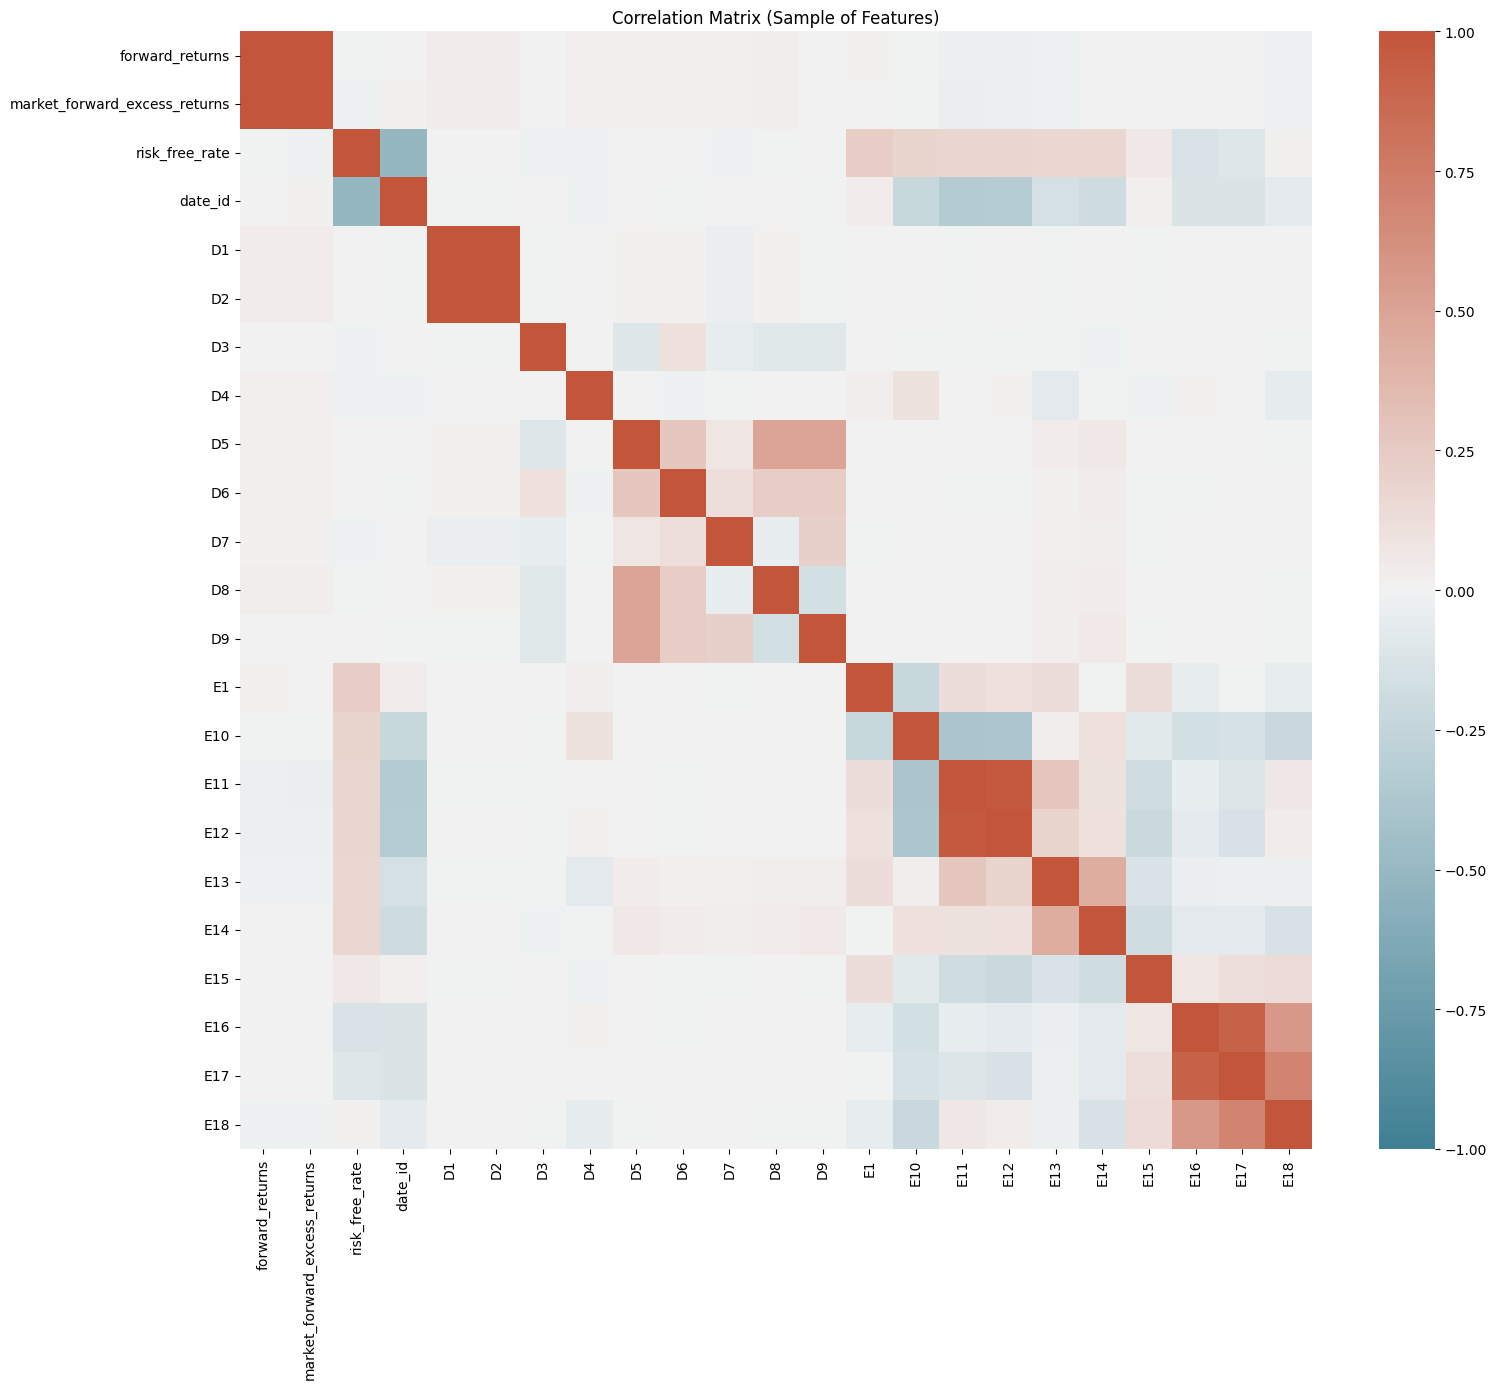


Top 10 correlaciones positivas con el objetivo:
market_forward_excess_returns    1.000000
forward_returns                  0.999943
D1                               0.033946
D2                               0.033946
D8                               0.024786
D4                               0.016943
D5                               0.016611
D6                               0.016600
D7                               0.010602
date_id                          0.009296
E1                               0.007038
Name: market_forward_excess_returns, dtype: float64

Top 10 correlaciones negativas con el objetivo:
D3                0.005559
E15               0.005476
D9                0.001070
E14               0.001042
E10              -0.002862
E18              -0.008163
risk_free_rate   -0.009386
E13              -0.009874
E12              -0.030927
E11              -0.032131
Name: market_forward_excess_returns, dtype: float64


In [ ]:
# Matriz de correlación

numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()

target_vars = ['forward_returns', 'market_forward_excess_returns', 'risk_free_rate']
available_targets = [col for col in target_vars if col in numeric_cols]

feature_sample = [col for col in numeric_cols if col not in target_vars][:20]
cols_for_corr = available_targets + feature_sample

if len(cols_for_corr) > 0:
    corr = df_cleaned[cols_for_corr].corr()

    plt.figure(figsize=(16, 14))
    sns.heatmap(corr,
                xticklabels=corr.columns,
                yticklabels=corr.columns,
                annot=False,
                cmap=sns.diverging_palette(220, 20, as_cmap=True),
                center=0,
                vmin=-1, vmax=1)
    plt.title('Correlation Matrix (Sample of Features)')
    plt.tight_layout()
    plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    if 'market_forward_excess_returns' in df_cleaned.columns:
        target_corr = corr['market_forward_excess_returns'].sort_values(ascending=False)
        print(f"\nTop 10 correlaciones positivas con el objetivo:")
        print(target_corr.head(11))  # 11 porque el objetivo se relaciona consigo mismo
        print(f"\nTop 10 correlaciones negativas con el objetivo:")
        print(target_corr.tail(10))

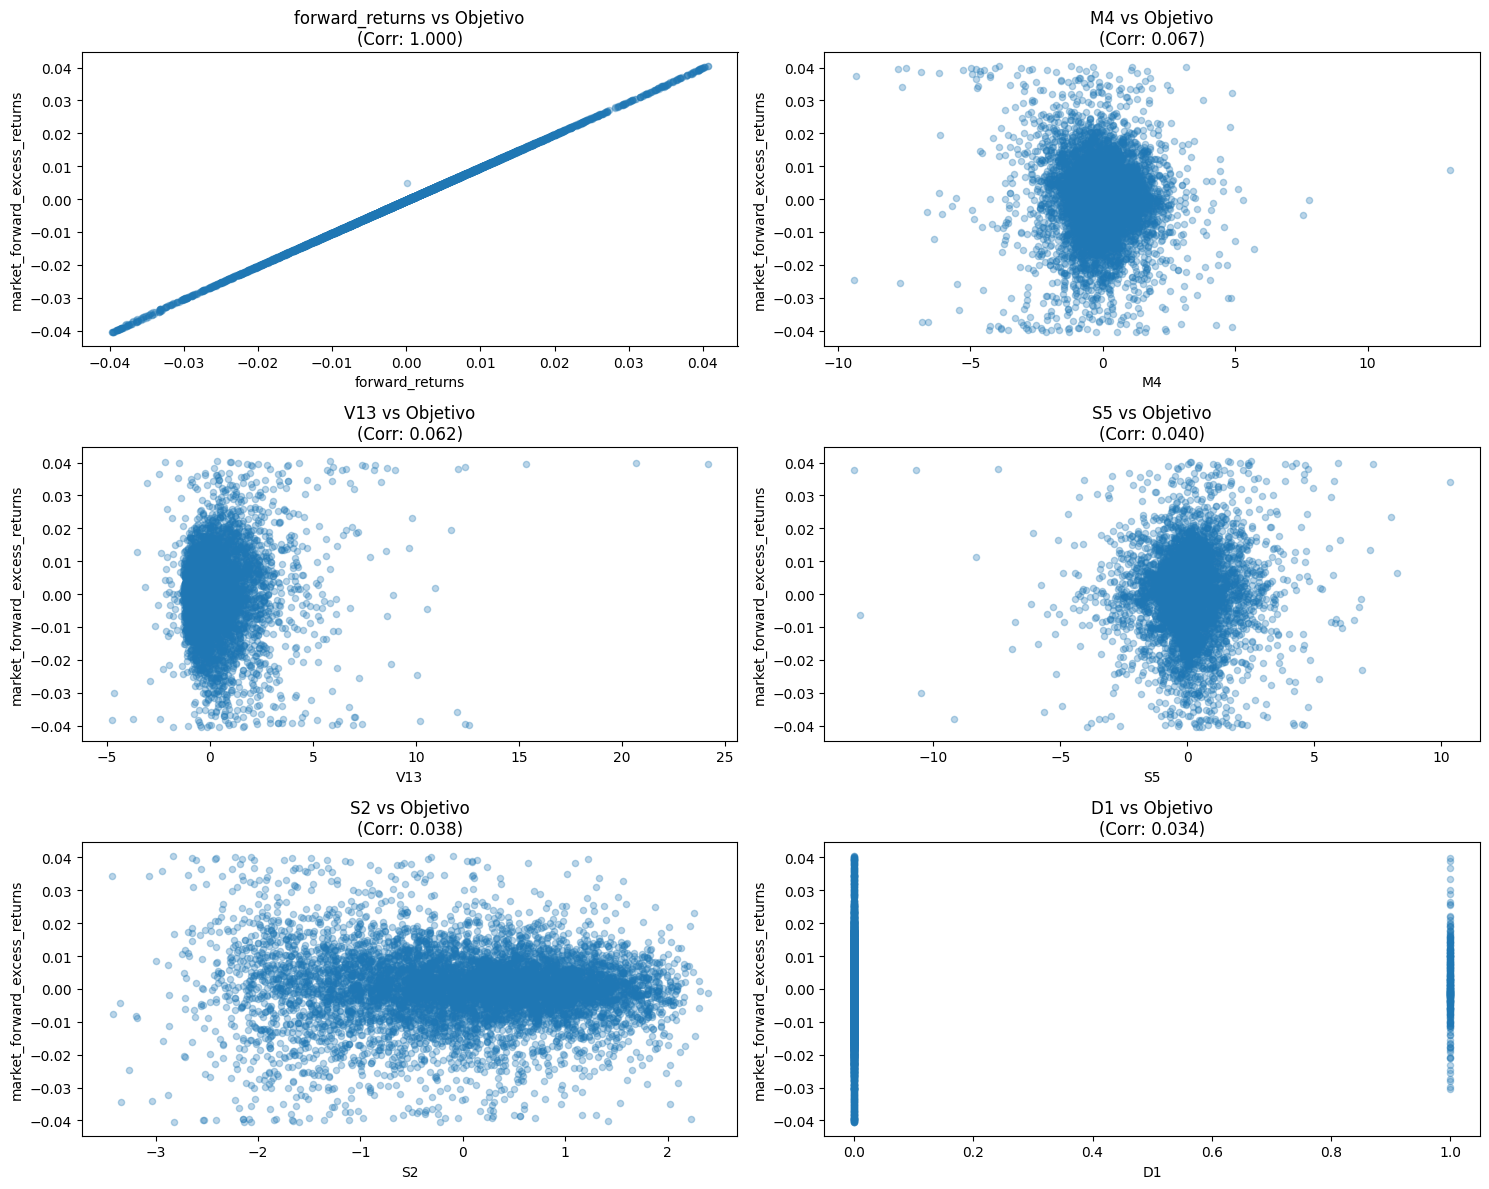

In [ ]:
# Diagrama de dispersión
if 'market_forward_excess_returns' in df_cleaned.columns:
    # Obtener las mejores características con correlación
    numeric_features = df_cleaned.select_dtypes(include=[np.number]).columns
    correlations = df_cleaned[numeric_features].corrwith(df_cleaned['market_forward_excess_returns']).abs()
    top_features = correlations.sort_values(ascending=False)[1:7]  # Top 6 (excluyendo el objetivo)

    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    axes = axes.ravel()

    for idx, feature in enumerate(top_features.index):
        df_cleaned.plot(kind='scatter',
                       x=feature,
                       y='market_forward_excess_returns',
                       alpha=0.3,
                       ax=axes[idx])
        axes[idx].set_title(f'{feature} vs Objetivo\n(Corr: {correlations[feature]:.3f})')
        axes[idx].set_ylabel('market_forward_excess_returns')

    plt.tight_layout()
    plt.savefig('scatterplots.png', dpi=300, bbox_inches='tight')
    plt.show()

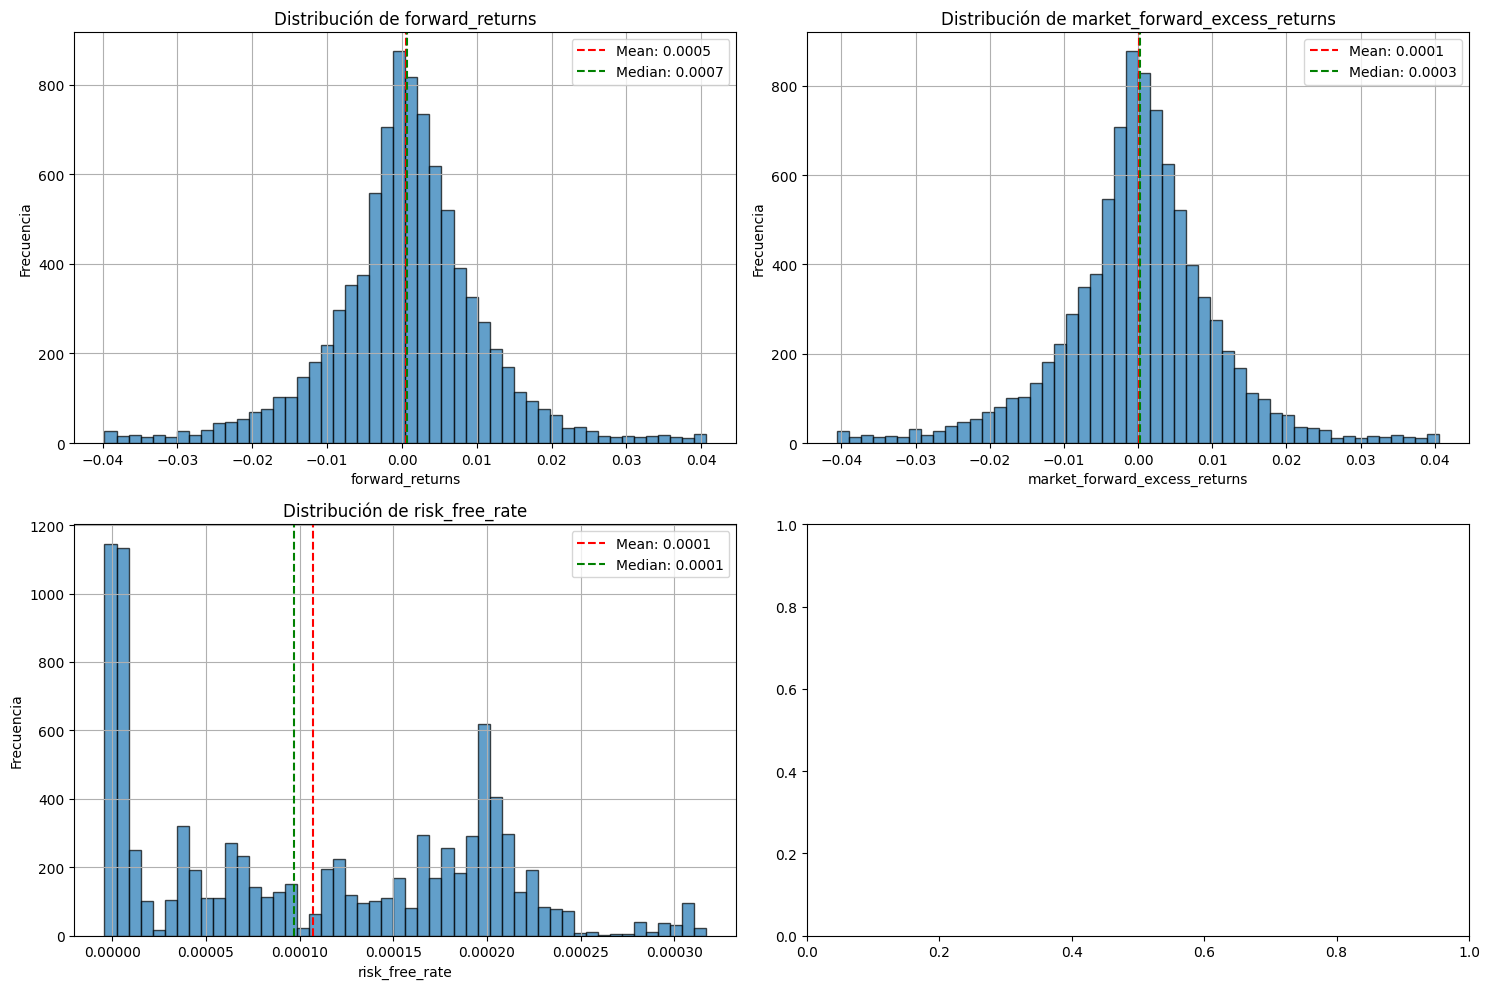

In [ ]:
# Histogramas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

# Graficar objetivo y variables clave
important_vars = ['forward_returns', 'market_forward_excess_returns', 'risk_free_rate']
plot_idx = 0

for var in important_vars:
    if var in df_cleaned.columns and plot_idx < 4:
        df_cleaned[var].hist(bins=50,
                            ax=axes[plot_idx],
                            edgecolor='black',
                            alpha=0.7)
        axes[plot_idx].set_title(f'Distribución de {var}')
        axes[plot_idx].set_xlabel(var)
        axes[plot_idx].set_ylabel('Frecuencia')

        # Agregar estadísticas
        mean_val = df_cleaned[var].mean()
        median_val = df_cleaned[var].median()
        axes[plot_idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')
        axes[plot_idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.4f}')
        axes[plot_idx].legend()

        plot_idx += 1

plt.tight_layout()
plt.savefig('histograms.png', dpi=300, bbox_inches='tight')
plt.show()


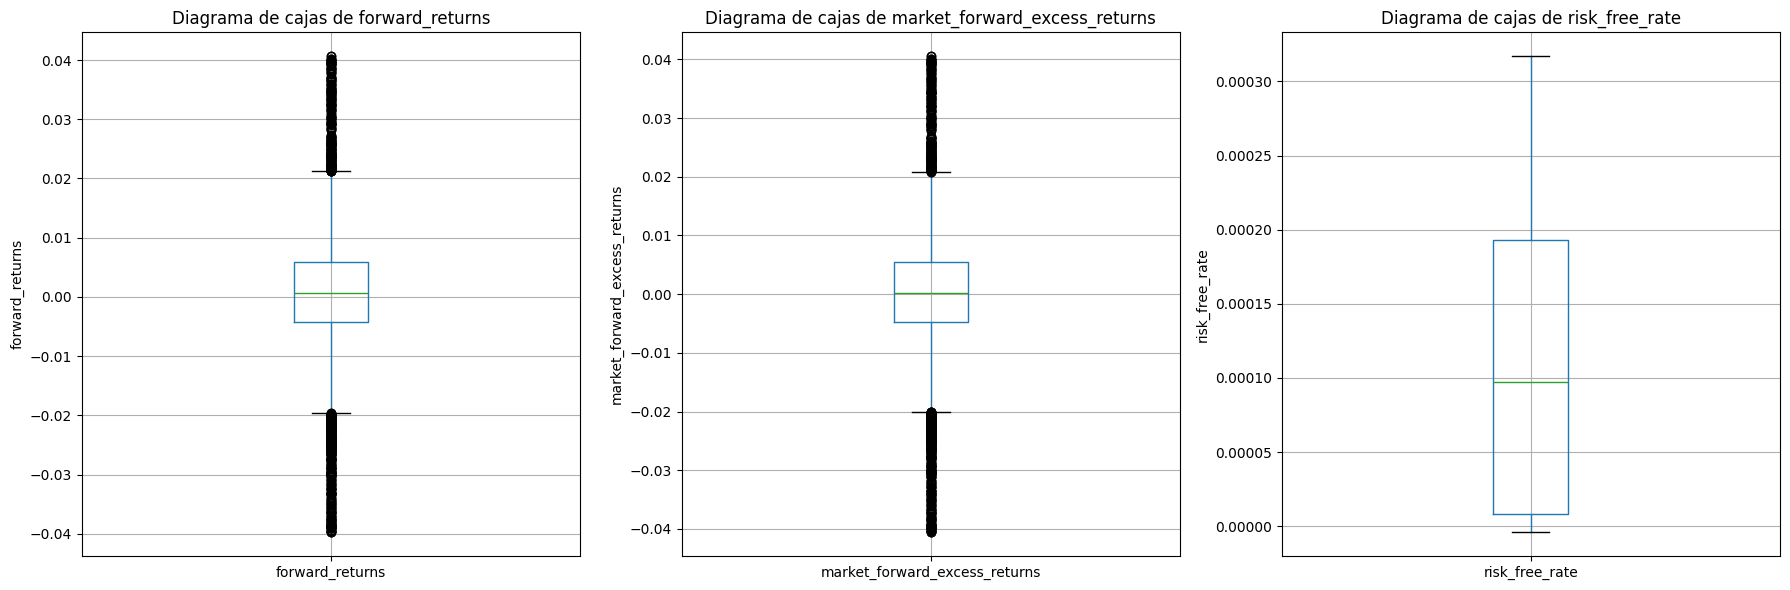

In [ ]:
# Diagramas de caja
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, var in enumerate(important_vars):
    if var in df_cleaned.columns and idx < 3:
        df_cleaned.boxplot(column=var, ax=axes[idx])
        axes[idx].set_title(f'Diagrama de cajas de {var}')
        axes[idx].set_ylabel(var)

plt.tight_layout()
plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

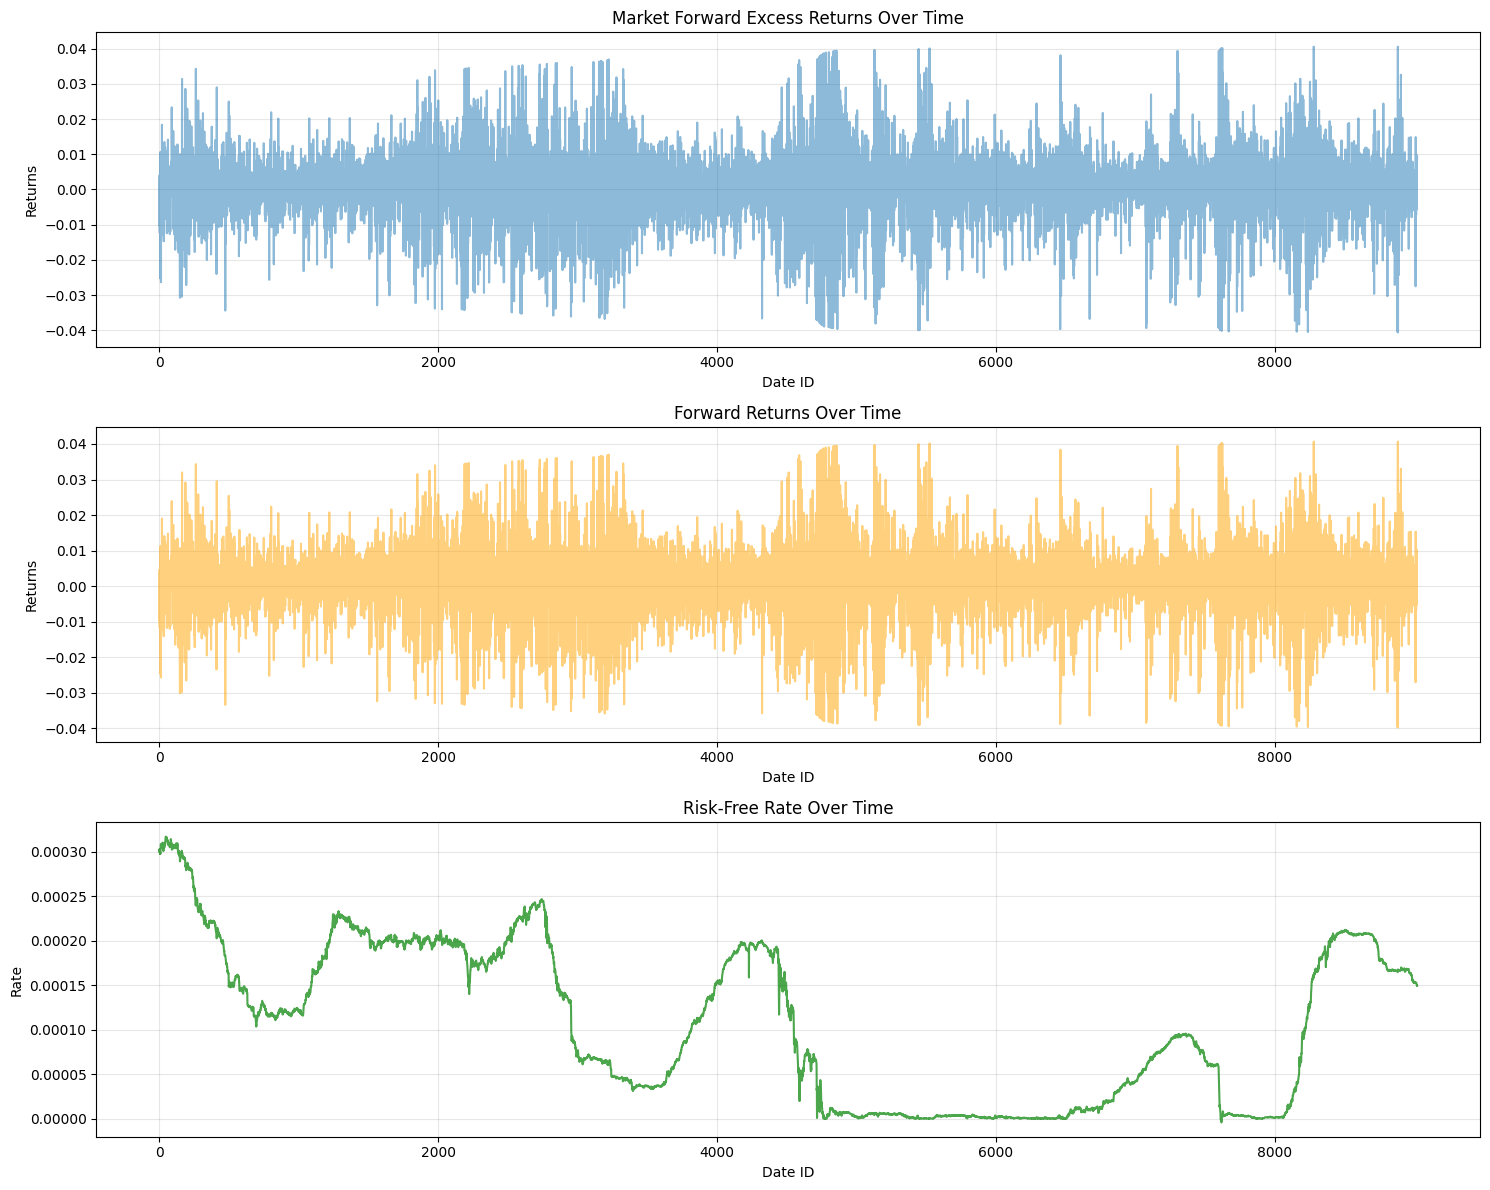

In [ ]:
# Análisis de series temporales para ver la evolución de los retornos
if 'date_id' in df_cleaned.columns and 'market_forward_excess_returns' in df_cleaned.columns:
    df_sorted = df_cleaned.sort_values('date_id')

    fig, axes = plt.subplots(3, 1, figsize=(15, 12))

    # Plot target over time
    axes[0].plot(df_sorted['date_id'], df_sorted['market_forward_excess_returns'], alpha=0.5)
    axes[0].set_title('Market Forward Excess Returns Over Time')
    axes[0].set_xlabel('Date ID')
    axes[0].set_ylabel('Returns')
    axes[0].grid(True, alpha=0.3)

    # Plot forward returns
    if 'forward_returns' in df_sorted.columns:
        axes[1].plot(df_sorted['date_id'], df_sorted['forward_returns'], alpha=0.5, color='orange')
        axes[1].set_title('Forward Returns Over Time')
        axes[1].set_xlabel('Date ID')
        axes[1].set_ylabel('Returns')
        axes[1].grid(True, alpha=0.3)

    # Plot risk-free rate
    if 'risk_free_rate' in df_sorted.columns:
        axes[2].plot(df_sorted['date_id'], df_sorted['risk_free_rate'], alpha=0.7, color='green')
        axes[2].set_title('Risk-Free Rate Over Time')
        axes[2].set_xlabel('Date ID')
        axes[2].set_ylabel('Rate')
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('time_series.png', dpi=300, bbox_inches='tight')
    plt.show()

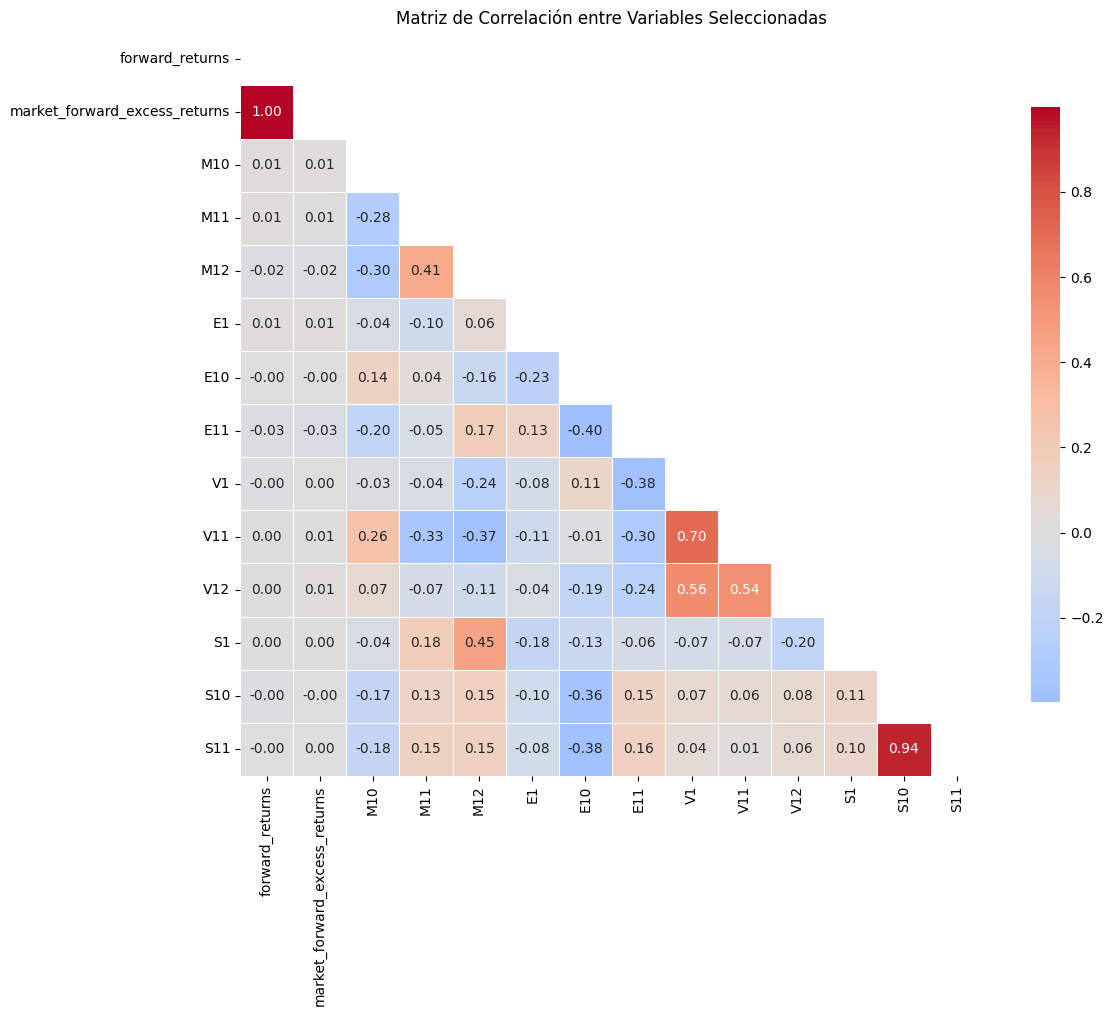

In [ ]:
df_clean = df_cleaned.copy()

correlation_vars = []
if 'forward_returns' in df_clean.columns:
    correlation_vars.append('forward_returns')
if 'market_forward_excess_returns' in df_clean.columns:
    correlation_vars.append('market_forward_excess_returns')

# Añadir algunas variables de cada categoría
for category in ['M', 'E', 'V', 'S', 'MOM']:
    cat_cols = [col for col in df_clean.columns if col.startswith(category)]
    if cat_cols:
        # Tomar máximo 3 variables de cada categoría para no hacer matriz muy grande
        correlation_vars.extend(cat_cols[:3])

# Filtrar para asegurar que existan en df_clean
correlation_vars = [col for col in correlation_vars if col in df_clean.columns]

if len(correlation_vars) > 1:

    # Calcular matriz de correlación
    corr_matrix = df_clean[correlation_vars].corr()

    # Visualizar matriz de correlación
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlación entre Variables Seleccionadas')
    plt.tight_layout()
    plt.show()

In [ ]:
    if 'forward_returns' in correlation_vars:
        forward_corr = corr_matrix['forward_returns'].drop('forward_returns')
        forward_corr = forward_corr.reindex(forward_corr.abs().sort_values(ascending=False).index)
        display(forward_corr.head(10))

,forward_returns
market_forward_excess_returns,0.999943
E11,-0.030872
M12,-0.023940
E1,0.008651
M10,0.007534
M11,0.006985
S10,-0.004976
V12,0.004864
S1,0.004663
V1,-0.004101


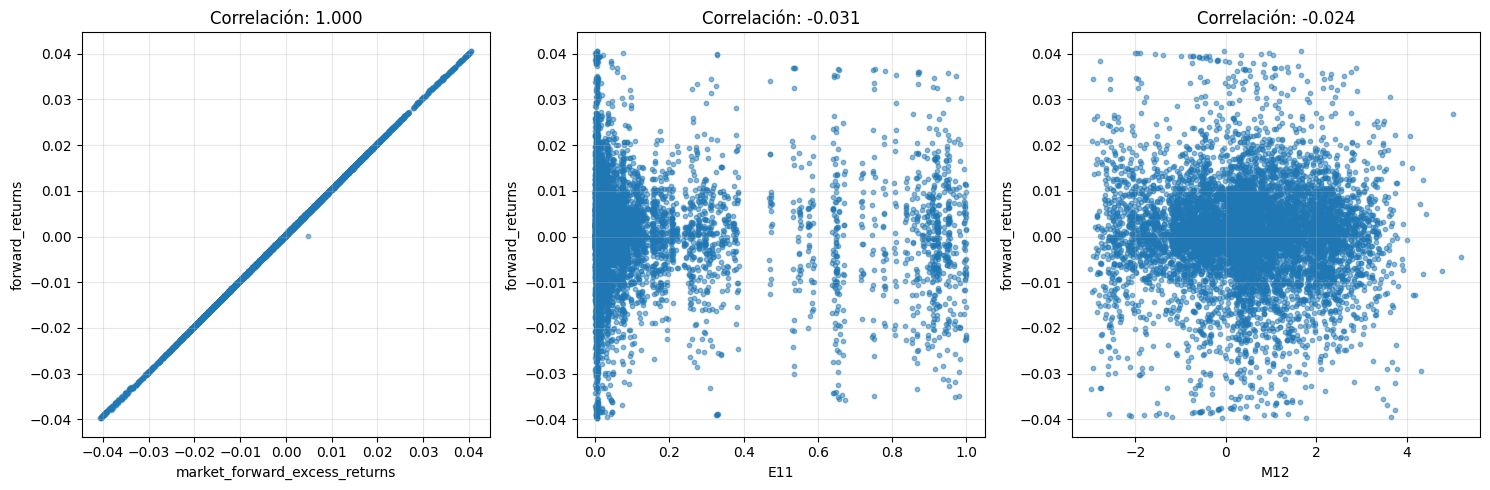

In [ ]:
    if 'forward_returns' in df_clean.columns:
        top_corr_vars = forward_corr.head(3).index.tolist()

        fig, axes = plt.subplots(1, min(3, len(top_corr_vars)), figsize=(15, 5))
        if len(top_corr_vars) == 1:
            axes = [axes]

        for i, var in enumerate(top_corr_vars[:3]):
            axes[i].scatter(df_clean[var], df_clean['forward_returns'], alpha=0.5, s=10)
            axes[i].set_xlabel(var)
            axes[i].set_ylabel('forward_returns')
            axes[i].set_title(f'Correlación: {forward_corr[var]:.3f}')
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

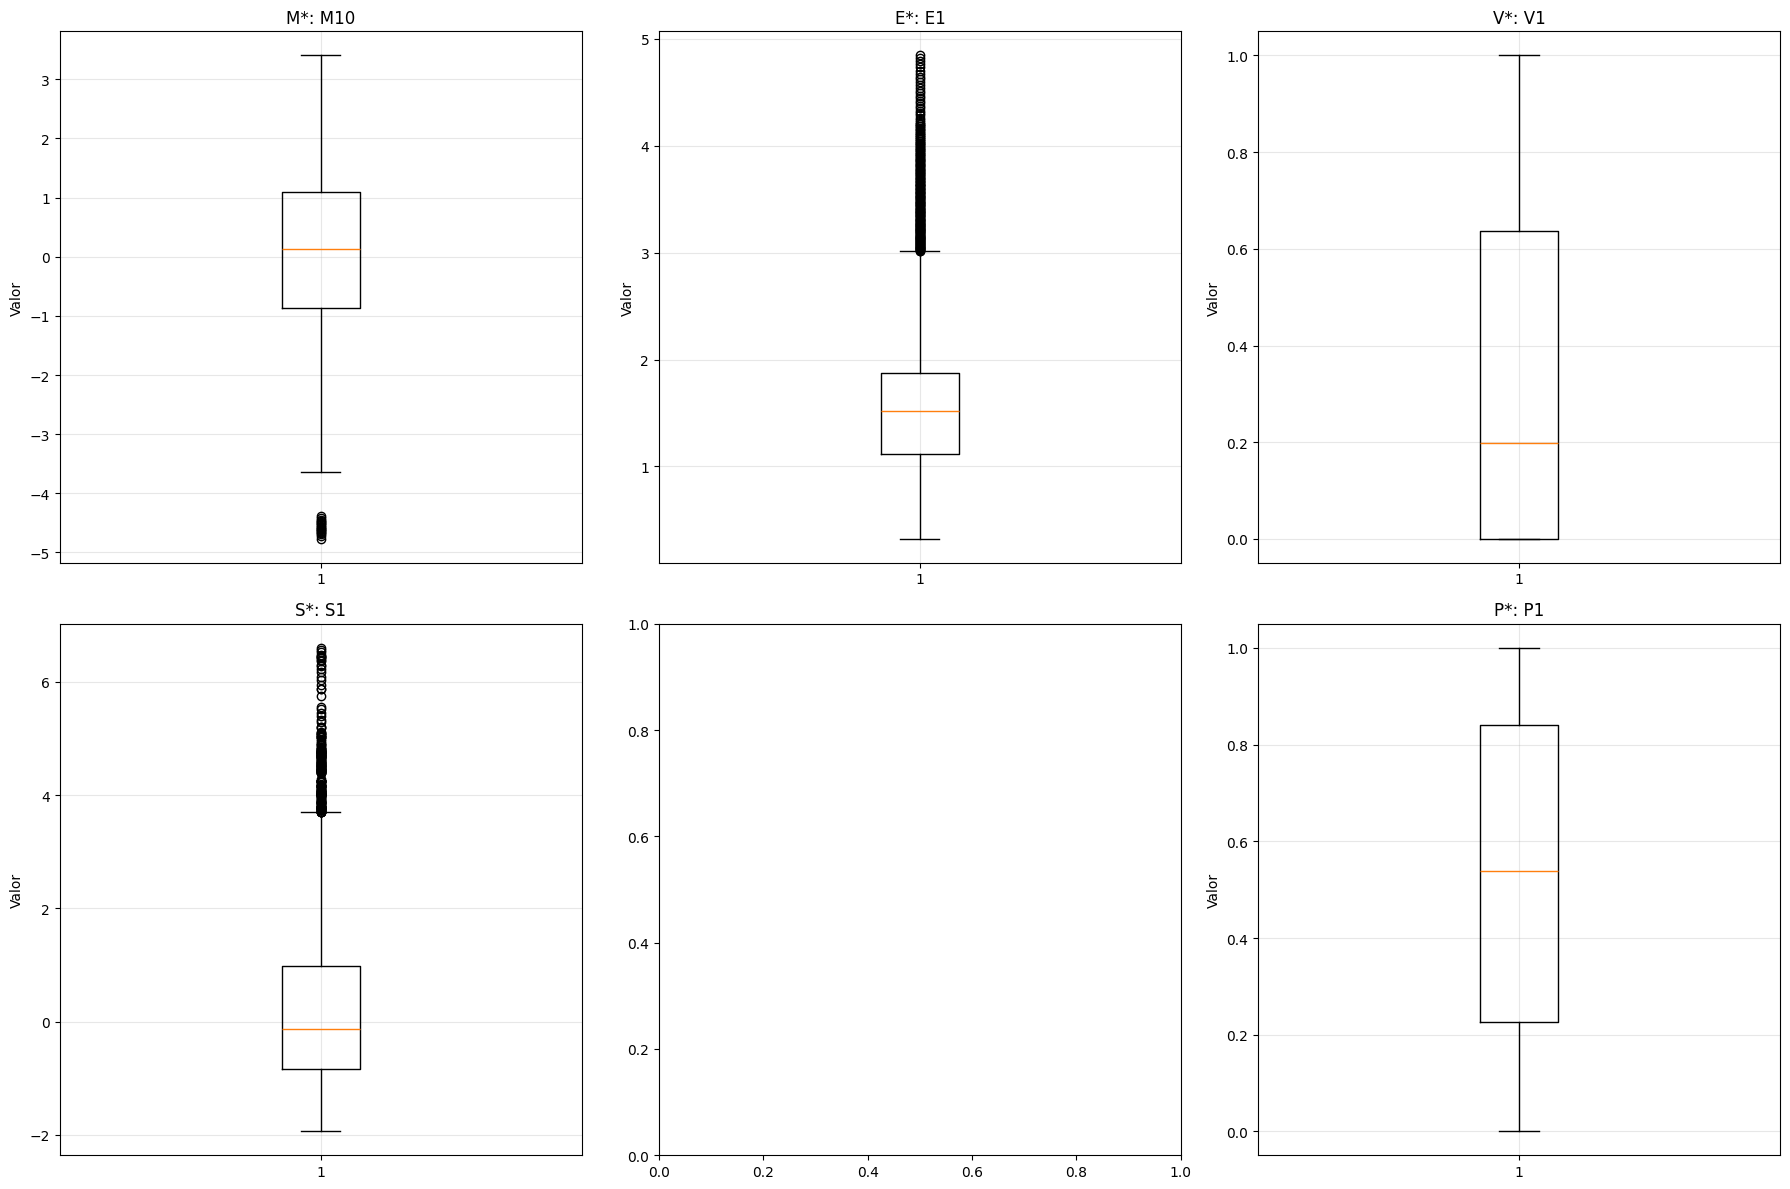

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

categories_to_plot = ['M', 'E', 'V', 'S', 'MOM', 'P']
for i, category in enumerate(categories_to_plot):
    if i < len(axes):
        cat_cols = [col for col in df_clean.columns if col.startswith(category)]
        if cat_cols:
            # Tomar una variable representativa de la categoría
            sample_var = cat_cols[0]
            axes[i].boxplot(df_clean[sample_var].dropna())
            axes[i].set_title(f'{category}*: {sample_var}')
            axes[i].set_ylabel('Valor')
            axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
